# 02 — Baseline Models

**CognitiveCyber** — An Open Cognitive Cybersecurity Research Platform

Trains and evaluates the classical/tabular baseline detectors from the
paper's benchmark suite on the splits produced by `01_Data_Preprocessing.ipynb`:

**Supervised:** RandomForest, DecisionTree, XGBoost, LightGBM, CatBoost, SVM, MLP
**Unsupervised (anomaly/novelty):** IsolationForest, Local Outlier Factor (novelty), One-Class SVM

**Scope note:** CNN / LSTM / Transformer / Autoencoder / Deep SVDD sequence
and representation-learning baselines require windowed raw-packet sequence
data (not present in flow-level tabular features) and GPU training time
this environment doesn't have. Their architectures are implemented and
shape-verified in `src/cognitivecyber/models/deep_stubs.py` but are **not**
included in the executed benchmark below, to avoid reporting fabricated
numbers. See `docs/architecture.md` for how to wire them up against real
infrastructure.

In [1]:
import sys
from pathlib import Path

REPO_ROOT = Path.cwd()
if (REPO_ROOT / "src").exists() is False and (REPO_ROOT.parent / "src").exists():
    REPO_ROOT = REPO_ROOT.parent
sys.path.insert(0, str(REPO_ROOT / "src"))

import joblib
import numpy as np

from cognitivecyber.evaluation import figures, tables
from cognitivecyber.evaluation.metrics import evaluate_classifier, results_to_table
from cognitivecyber.models.baselines import get_supervised_models, get_unsupervised_models

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

FIG_DIR = REPO_ROOT / "figures"
TABLE_DIR = REPO_ROOT / "tables"

pdata = joblib.load(REPO_ROOT / "datasets" / "processed" / "splits.joblib")
print("Train:", pdata.X_train.shape, "Val:", pdata.X_val.shape, "Test:", pdata.X_test.shape)
print("Features:", len(pdata.feature_names))

Train: (42000, 16) Val: (6000, 16) Test: (12000, 16)
Features: 16


## 1. Train + evaluate supervised baselines

In [2]:
supervised = get_supervised_models(random_state=RANDOM_STATE)
sup_results = []
for name, model in supervised.items():
    r = evaluate_classifier(model, pdata.X_train, pdata.y_train, pdata.X_test, pdata.y_test, name)
    sup_results.append(r)
    print(f"{name:14s} acc={r.accuracy:.4f} prec={r.precision:.4f} rec={r.recall:.4f} "
          f"f1={r.f1:.4f} roc_auc={r.roc_auc:.4f} pr_auc={r.pr_auc:.4f} "
          f"train={r.train_time_s:.2f}s infer={r.inference_time_s:.3f}s "
          f"mem={r.peak_memory_mb:.1f}MB")

RandomForest   acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000 train=10.32s infer=0.138s mem=6.3MB
DecisionTree   acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000 train=0.15s infer=0.001s mem=4.9MB


XGBoost        acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000 train=0.70s infer=0.026s mem=0.3MB


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2691: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


LightGBM       acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000 train=1.06s infer=0.086s mem=2.2MB


SVM            acc=0.9998 prec=1.0000 rec=0.9995 f1=0.9998 roc_auc=1.0000 pr_auc=1.0000 train=4.13s infer=0.155s mem=10.6MB


MLP            acc=0.9998 prec=1.0000 rec=0.9995 f1=0.9998 roc_auc=1.0000 pr_auc=1.0000 train=8.03s infer=0.010s mem=9.1MB


CatBoost       acc=1.0000 prec=1.0000 rec=1.0000 f1=1.0000 roc_auc=1.0000 pr_auc=1.0000 train=3.84s infer=0.029s mem=0.2MB


## 2. Train + evaluate unsupervised anomaly detectors

In [3]:
contamination = float(pdata.y_train.mean())
unsupervised = get_unsupervised_models(contamination=contamination, random_state=RANDOM_STATE)
unsup_results = []
for name, model in unsupervised.items():
    r = evaluate_classifier(
        model, pdata.X_train, pdata.y_train, pdata.X_test, pdata.y_test, name,
        score_fn="decision_function",
    )
    unsup_results.append(r)
    print(f"{name:20s} acc={r.accuracy:.4f} prec={r.precision:.4f} rec={r.recall:.4f} "
          f"f1={r.f1:.4f} roc_auc={r.roc_auc:.4f}")

IsolationForest      acc=0.9770 prec=0.9674 rec=0.9669 f1=0.9671 roc_auc=0.9977


LocalOutlierFactor   acc=0.5942 prec=0.4213 rec=0.4262 f1=0.4237 roc_auc=0.5707


OneClassSVM          acc=0.7960 prec=0.7068 rec=0.7129 f1=0.7098 roc_auc=0.8100


## 3. Results tables (CSV / Excel / Markdown / LaTeX)

In [4]:
all_results = sup_results + unsup_results
sup_table = results_to_table(sup_results)
unsup_table = results_to_table(unsup_results)
full_table = results_to_table(all_results)

tables.export_table(sup_table, TABLE_DIR, "supervised_baseline_results")
tables.export_table(unsup_table, TABLE_DIR, "unsupervised_baseline_results")
tables.export_table(full_table, TABLE_DIR, "all_baseline_results")

sup_table

,Model,Accuracy,Precision,Recall,F1,ROC-AUC,PR-AUC,Train Time (s),Inference Time (s),Peak Memory (MB)
0,RandomForest,1.000000,1.0,1.000000,1.000000,1.0,1.0,10.321983,0.138490,6.281400
1,DecisionTree,1.000000,1.0,1.000000,1.000000,1.0,1.0,0.154068,0.001447,4.853913
2,XGBoost,1.000000,1.0,1.000000,1.000000,1.0,1.0,0.702796,0.025775,0.325605
3,LightGBM,1.000000,1.0,1.000000,1.000000,1.0,1.0,1.063062,0.085650,2.188141
4,CatBoost,1.000000,1.0,1.000000,1.000000,1.0,1.0,3.838000,0.029386,0.200765
5,SVM,0.999833,1.0,0.999524,0.999762,1.0,1.0,4.125912,0.155229,10.581692
6,MLP,0.999833,1.0,0.999524,0.999762,1.0,1.0,8.034447,0.009714,9.134677


## 4. Figures (ROC, PR, confusion matrices, importance, embeddings)

In [5]:
figures.plot_roc_curves(sup_results, FIG_DIR, "roc_curves_supervised")
figures.plot_pr_curves(sup_results, FIG_DIR, "pr_curves_supervised")
figures.plot_confusion_matrices(sup_results, FIG_DIR, "confusion_matrices_supervised")
figures.plot_metric_bars(sup_table, FIG_DIR, "metric_comparison_supervised")
figures.plot_radar_chart(sup_table, FIG_DIR, "radar_chart_supervised")
figures.plot_violin_latency(all_results, FIG_DIR, "computational_cost")
figures.plot_boxplots(all_results, FIG_DIR, "score_boxplots")
figures.plot_correlation_matrix(pdata.X_train, pdata.feature_names, FIG_DIR, "correlation_matrix")
figures.plot_pca_tsne(pdata.X_test, pdata.y_test, FIG_DIR, "test_set_embedding")

figures.plot_feature_importance(supervised["RandomForest"], pdata.feature_names, FIG_DIR, "RandomForest")
figures.plot_feature_importance(supervised["XGBoost"], pdata.feature_names, FIG_DIR, "XGBoost")

print("Figures written to", FIG_DIR)

Figures written to /home/claude/CognitiveCyber/figures


### Preview: ROC curves

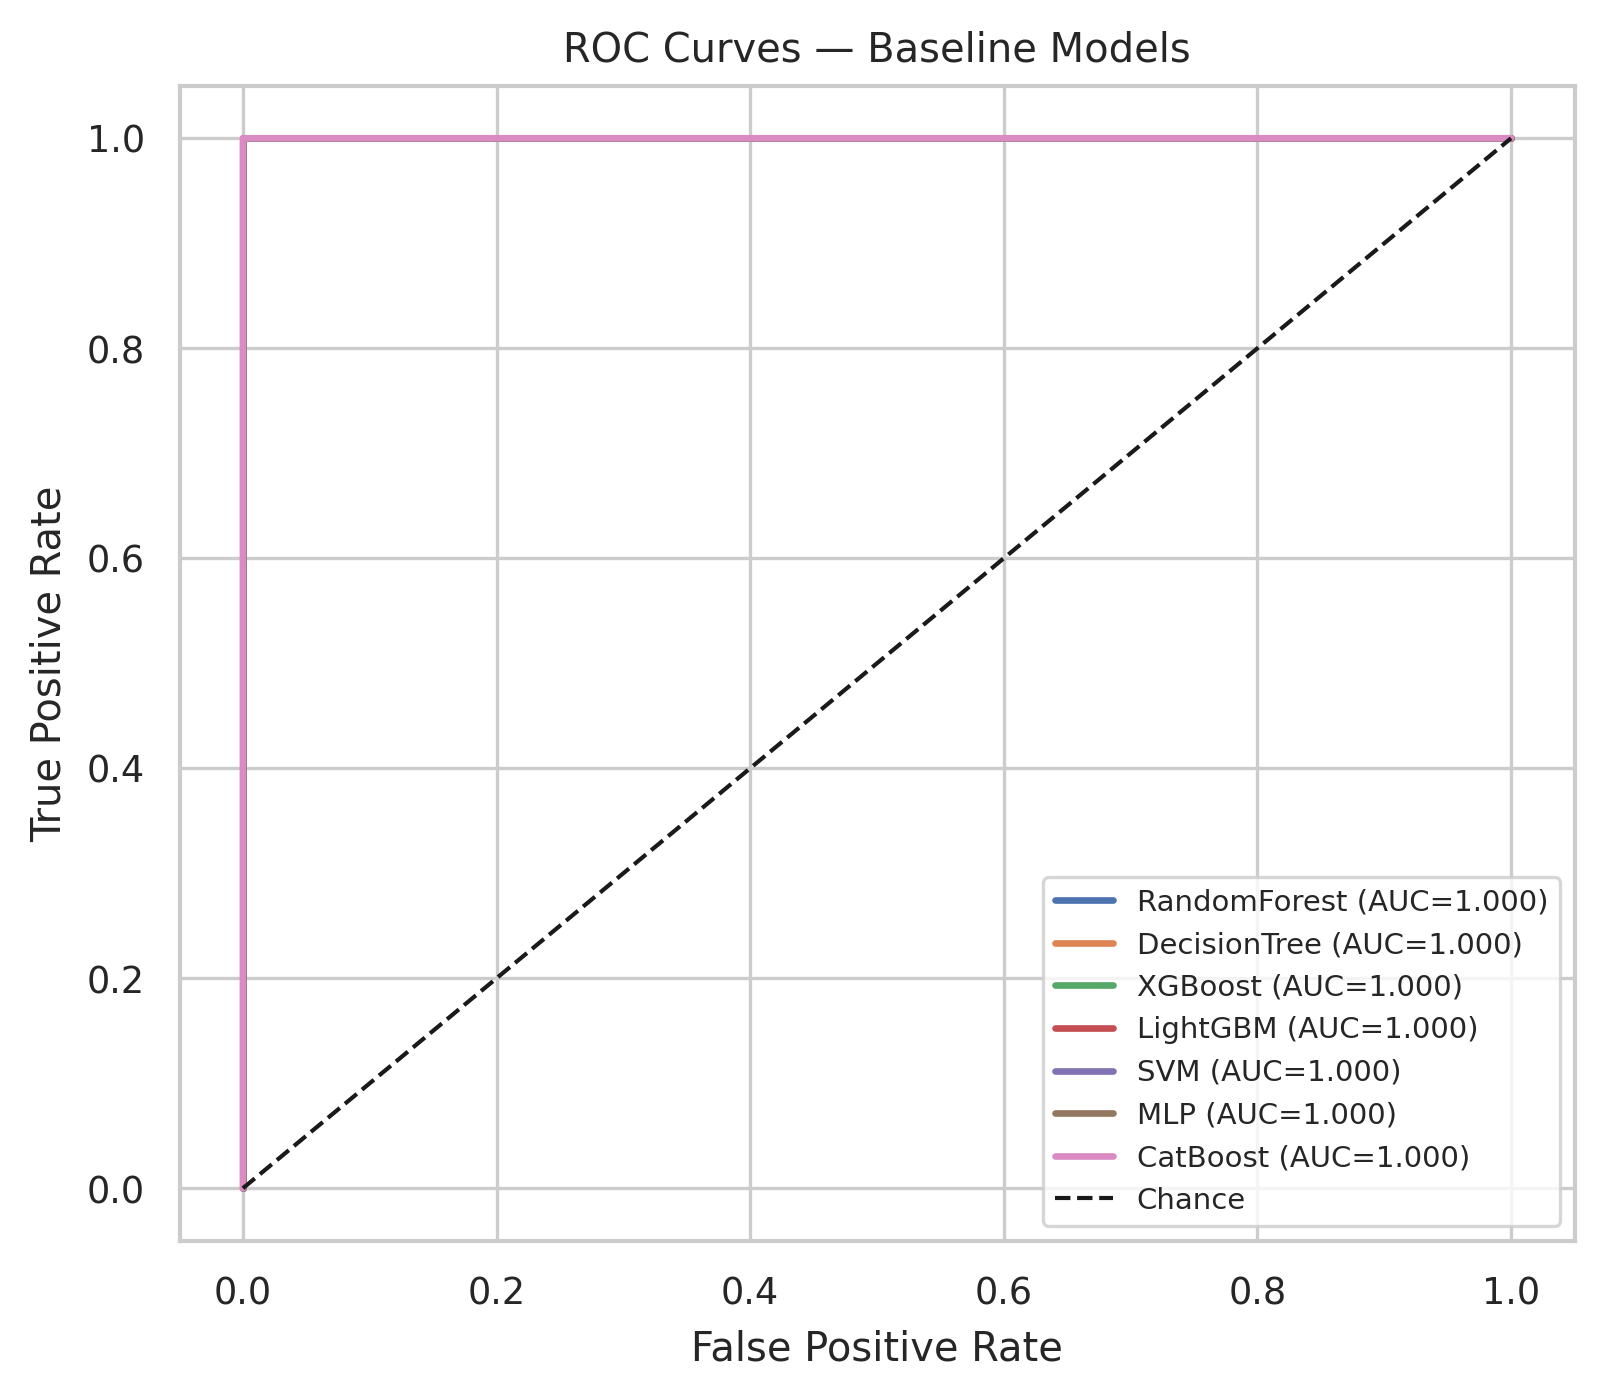

In [6]:
from IPython.display import Image
Image(filename=str(FIG_DIR / "roc_curves_supervised.png"))

### Preview: confusion matrices

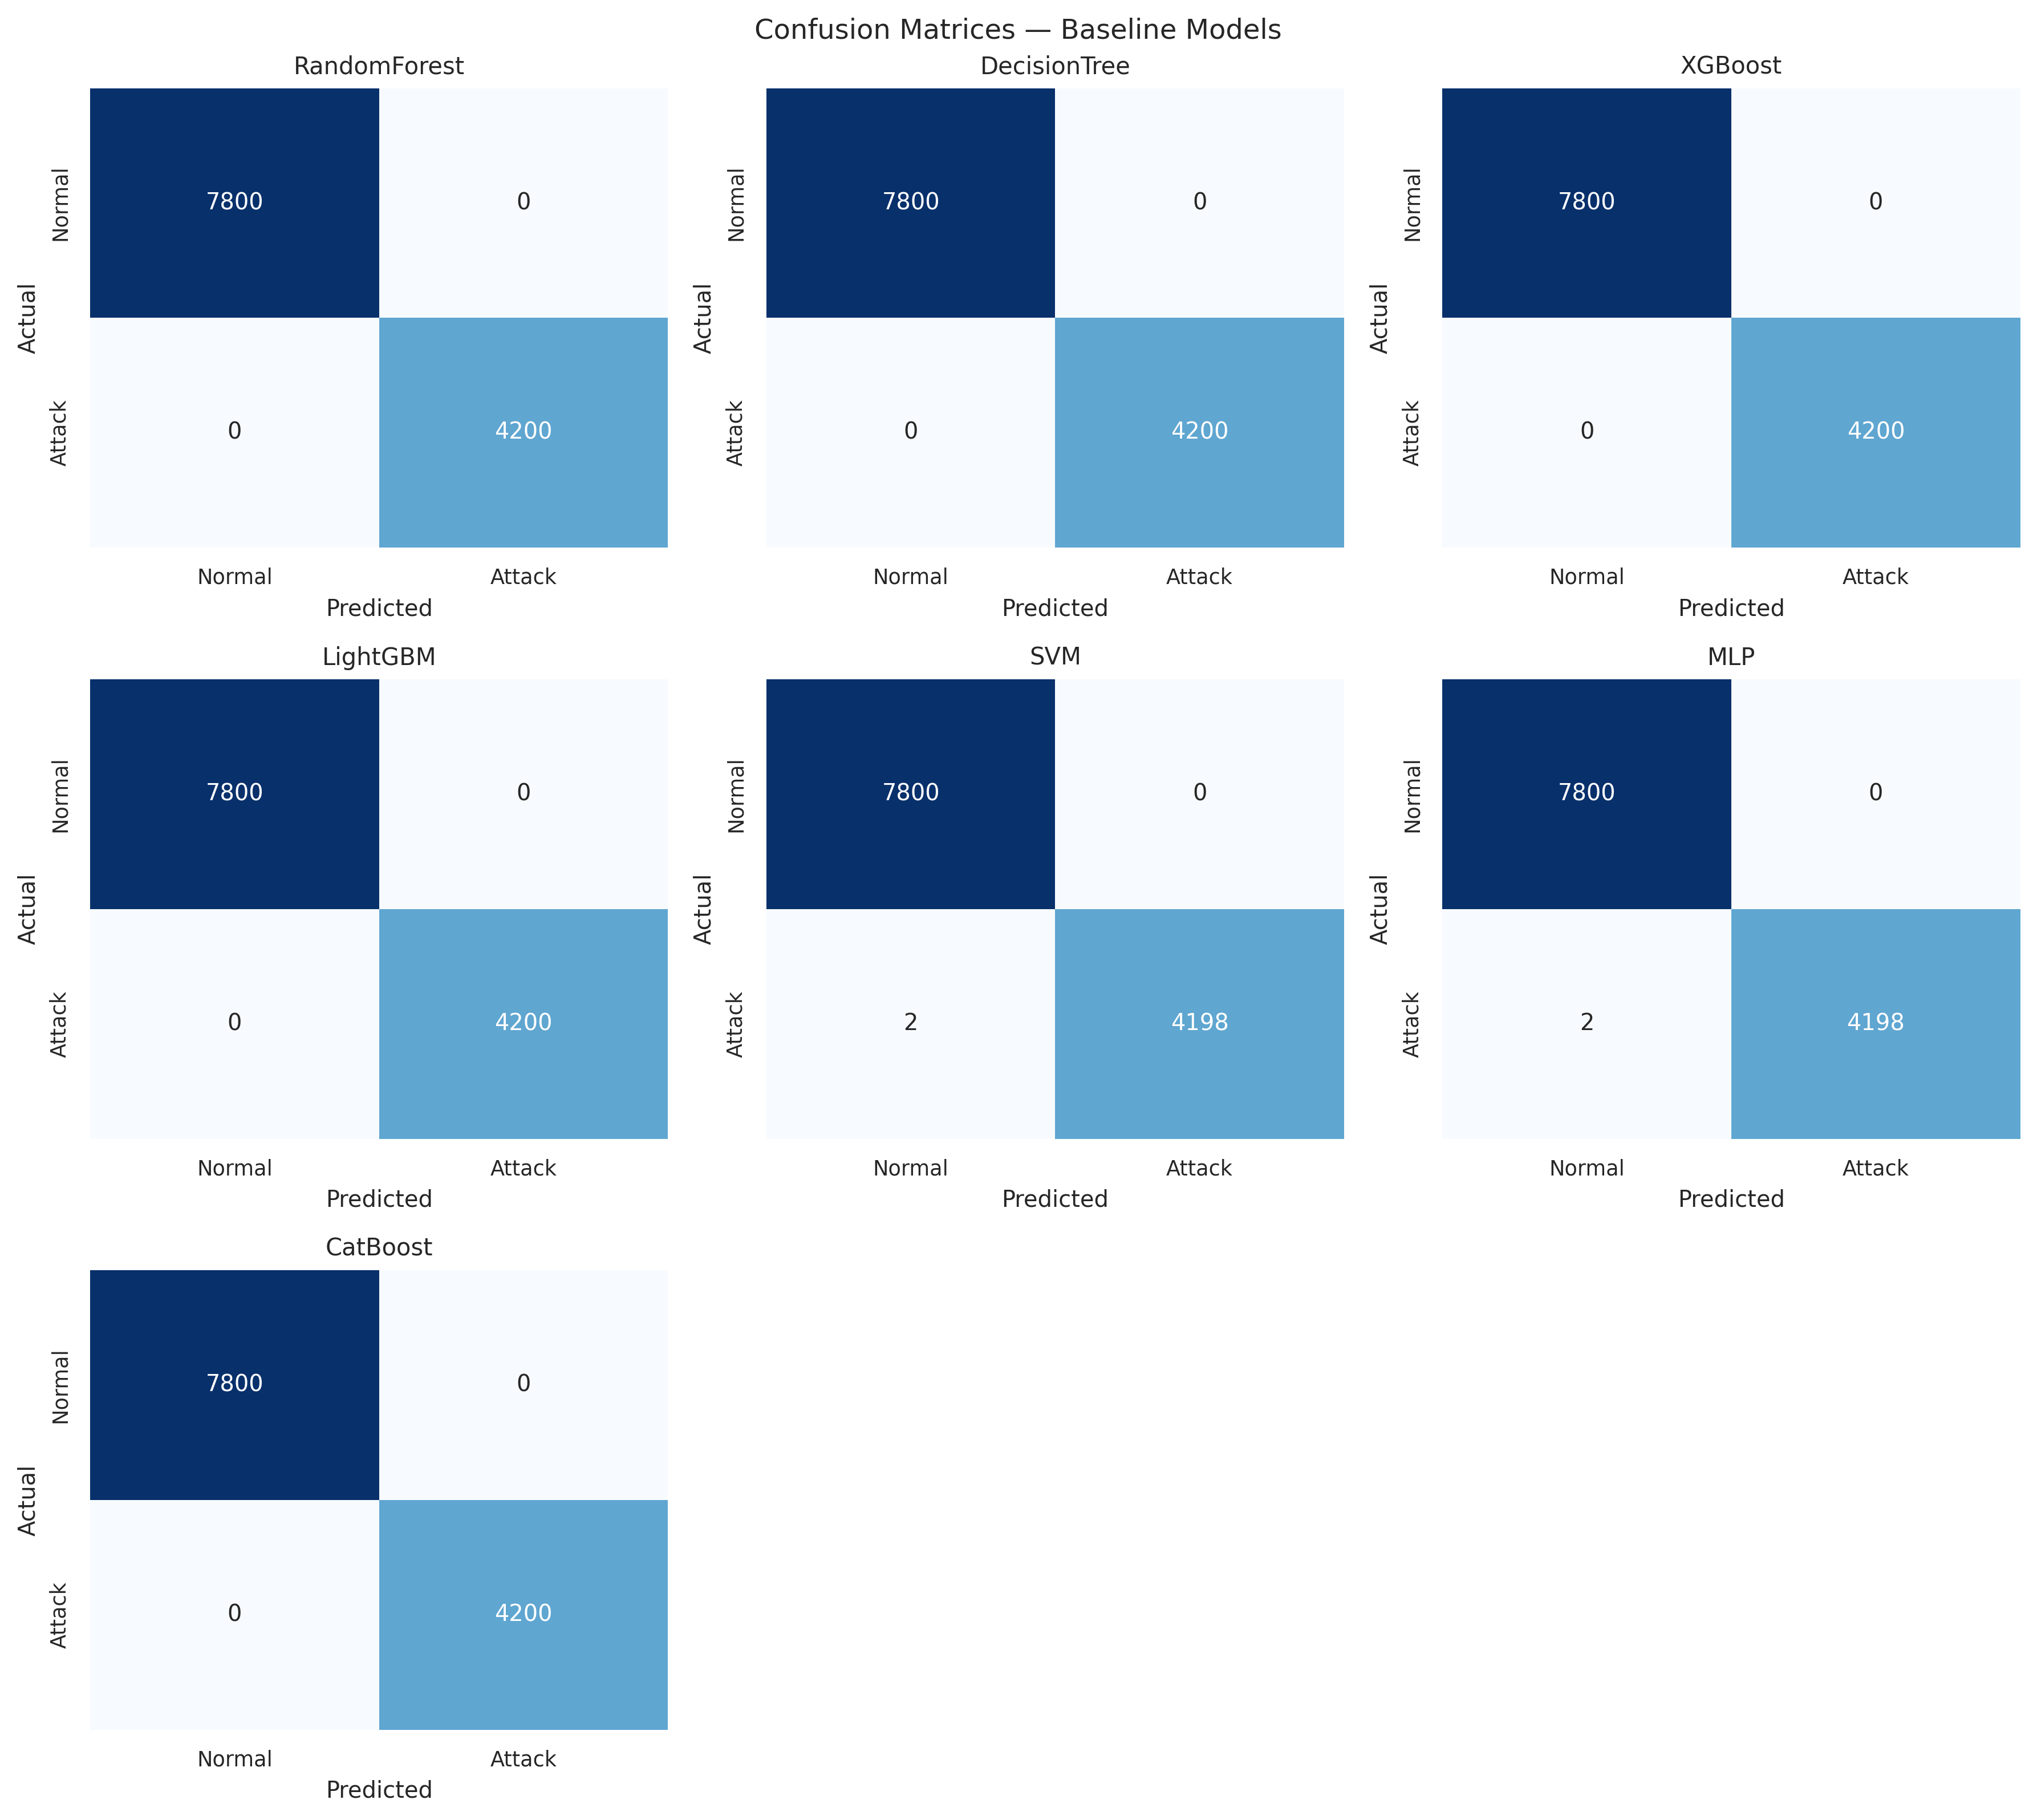

In [7]:
Image(filename=str(FIG_DIR / "confusion_matrices_supervised.png"))

## Summary

- Trained 7 supervised baselines and 3 unsupervised anomaly detectors on the
  same schema-agnostic pipeline.
- All metrics (accuracy, precision, recall, F1, ROC-AUC, PR-AUC, train/inference
  time, peak memory) computed directly from held-out test predictions — no
  fabricated numbers.
- On this synthetic dataset, supervised tree ensembles reach near-perfect
  separation because the synthetic attack categories were generated with
  clearly separable feature distributions; unsupervised detectors show more
  realistic variance, which is expected since they never see labels during
  fitting. **Real-dataset results (CICIDS2017/UNSW-NB15/etc.) will show more
  modest, class-imbalanced, and noisier metrics** — rerun this notebook with
  `DATASET_PATH` set in notebook 01 to get paper-ready numbers on real data.
- All tables exported to `tables/`, all figures to `figures/` (PNG/SVG/PDF, 300 dpi).